This notebook trains 2 machine learning models.

The preprocessing of the transcription data includes:
- Run the spaCy pipeline that includes **named entity recognition**
- Carry out lemmatization and remove clinically irrelevant stop words 

The ML pipeline is structured like this:
- Split the data into a training and testing dataset.
- Have a cross validation of a linear SVC pipeline and a multinomial logistic regression
- Determine the model with the best test matrix and fit it on the training dataset.

In [1]:
# Import the relevant libraries for preprocessing
import pandas as pd
import spacy

In [2]:
# Load the appropriate data
super_clinical_mtsamples = pd.read_csv("../data/super_clinical_mtsamples.csv")
super_clinical_mtsamples.head()

,description,medical_specialty,sample_name,transcription,keywords,medical_specialty_clean,clinical_superclass
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",Allergy / Immunology,internal_and_systemic_medicine
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",Bariatrics,surgical_and_procedural
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",Bariatrics,surgical_and_procedural
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",Cardiovascular / Pulmonary,internal_and_systemic_medicine
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",Cardiovascular / Pulmonary,internal_and_systemic_medicine


In [3]:
# Load the spaCy model
# nlp = spacy.load("en_core_sci_sm") # The clinical dataset is not available for download
nlp = spacy.load("en_core_web_sm")

# Load the clinical stopwords
with open('../data/clinical-stopwords.txt', 'r') as file:
    custom_stopwords = set(file.read().splitlines())

# Create a function that carries out the preprocessing
def extract_and_lemmatize_entities(text):
    # Handle missing/NaN transcripts gracefully
    if not isinstance(text, str):
        return ""
        
    doc = nlp(text)
    processed_entities = []
    
    # Iterate ONLY through the recognized named entities
    for ent in doc.ents:
        # Lemmatize and filter out custom stopwords and punctuation
        ent_tokens = [
            token.lemma_.lower() for token in ent 
            if token.lemma_.lower() not in custom_stopwords 
            and not token.is_punct
            and not token.is_space
        ]
        
        # If tokens remain after filtering, join them back into a string
        if ent_tokens:
            processed_entities.append(" ".join(ent_tokens))
            
    # Return a single string of all processed entities for TF-IDF
    return " ".join(processed_entities)

In [4]:
# Compute the entities using the above function
super_clinical_mtsamples['entity_features'] = super_clinical_mtsamples['transcription'].apply(extract_and_lemmatize_entities)

In [5]:
# Saving the data with entities to avoid rerunning the processing
super_clinical_mtsamples.to_pickle("../.private/super_clinical_mtsamples_preprocessed.pkl")

In [6]:
# Load the data that is preprocessed
super_clinical_mtsamples = pd.read_pickle("../.private/super_clinical_mtsamples_preprocessed.pkl")

## Carry out the machine learning pipeline

This pipeline carries out the linearSVC and multinomial logistic regression while creating a cross validation 5 times

In [7]:
# Load the required libraries for this section
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import warnings


In [8]:
# Split the data into a test and split section
# Define Features (X) and Target (y)
X = super_clinical_mtsamples['entity_features']
y = super_clinical_mtsamples['clinical_superclass']

# Train/Test Split (30% test size, random_state 42, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# For use with XGBoost
label_encoder = LabelEncoder()

# Transform the y from both training and testing data
y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

# Manually compute sample weights
xgb_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_xgb)

In [9]:
# Define the pipeline 
# LinearSVC Pipeline
svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, strip_accents='unicode')),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, max_iter=3000))
])

logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, strip_accents='unicode')),
    ('clf', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=3000 
    ))
])

xgboost_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, strip_accents='unicode')),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
        tree_method='hist',
        n_jobs=1  
    ))
])

In [10]:
# Suppress convergence warnings during the grid search
warnings.filterwarnings("ignore", category=UserWarning)

svc_param_grid = [
    {   
        'tfidf__max_features': [5000, 10000],
        'tfidf__min_df': [2, 5],
        'tfidf__max_df': [0.85, 0.90, 0.95],
        'tfidf__norm': ['l2'],
        'tfidf__sublinear_tf': [True, False],  # Fixed double underscore
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'clf__penalty': ['l2'], 
        'clf__loss': ['hinge', 'squared_hinge'], 
        'clf__C': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0],
        'clf__dual': ['auto']
    },
    {   
        'tfidf__max_features': [5000, 10000],
        'tfidf__min_df': [2, 5],
        'tfidf__max_df': [0.85, 0.90, 0.95],
        'tfidf__norm': ['l2'],
        'tfidf__sublinear_tf': [True, False],  # Fixed double underscore
        'clf__penalty': ['l1'], 
        'clf__loss': ['squared_hinge'], 
        'clf__C': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0],
        'clf__dual': [False]
    }
]

logreg_param_grid = [
    {   
        'tfidf__max_features': [5000, 10000],
        'tfidf__min_df': [2, 5],
        'tfidf__max_df': [0.85, 0.90, 0.95],
        'tfidf__norm': ['l2'],
        'tfidf__sublinear_tf': [True, False],  # Fixed double underscore
        'clf__l1_ratio': [0],                # Fixed l1_penalty -> penalty
        'clf__solver': ['lbfgs', 'saga'], 
        'clf__C': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]
    },
    {   
        'tfidf__max_features': [5000, 10000],
        'tfidf__min_df': [2, 5],
        'tfidf__max_df': [0.85, 0.90, 0.95],
        'tfidf__norm': ['l2'],
        'tfidf__sublinear_tf': [True, False],  # Fixed double underscore
        'clf__l1_ratio': [1],                # Fixed l1_penalty -> penalty
        'clf__solver': ['saga'], 
        'clf__C': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]
    }
]

# xgboost_param_grid = [
#     {   
#         'tfidf__max_features': [5000, 10000],
#         'tfidf__min_df': [2, 5],
#         'tfidf__max_df': [0.85, 0.90, 0.95],
#         'tfidf__norm': ['l2'],
#         'tfidf__sublinear_tf': [True, False],  # Fixed double underscore
#         'clf__max_depth': [3, 5, 7],
#         'clf__learning_rate': [0.01, 0.1, 0.2],
#         'clf__n_estimators': [100, 200, 300],
#         'clf__subsample': [0.8, 1.0] 
#     },
# ]

# Run Grid Searches
print("Running GridSearchCV for LinearSVC Pipeline...")
svc_grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=svc_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1 
)
svc_grid.fit(X_train, y_train)

print("Running GridSearchCV for Logistic Regression Pipeline...")
logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
logreg_grid.fit(X_train, y_train)

# print("Running GridSearchCV for XGBoost Pipeline...")
# xgboost_grid = GridSearchCV(
#     estimator=xgboost_pipeline,
#     param_grid=xgboost_param_grid,
#     cv=5,
#     scoring='f1_macro',
#     n_jobs=-1
# )
# # Fixed parameter routing using clf__sample_weight
# xgboost_grid.fit(
#     X_train, 
#     y_train_xgb, 
#     clf__sample_weight=xgb_sample_weights
# )

Running GridSearchCV for LinearSVC Pipeline...


Running GridSearchCV for Logistic Regression Pipeline...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clf__C': [0.001, 0.01, ...], 'clf__l1_ratio': [0], 'clf__solver': ['lbfgs', 'saga'], 'tfidf__max_df': [0.85, 0.9, ...], ...}, {'clf__C': [0.001, 0.01, ...], 'clf__l1_ratio': [1], 'clf__solver': ['saga'], 'tfidf__max_df': [0.85, 0.9, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=c

In [11]:
print("\n--- Advanced Tuning Results (SpaCy NER + TF-IDF) ---")
print(f"Best LinearSVC F1-Macro: {svc_grid.best_score_:.4f}")
print("LinearSVC Best Params:", svc_grid.best_params_)

print(f"\nBest LogReg F1-Macro:    {logreg_grid.best_score_:.4f}")
print("LogReg Best Params:", logreg_grid.best_params_)

# print(f"\nBest XGBoost F1-Macro:   {xgboost_grid.best_score_:.4f}")
# print("XGBoost Best Params:", xgboost_grid.best_params_)


--- Advanced Tuning Results (SpaCy NER + TF-IDF) ---
Best LinearSVC F1-Macro: 0.5034
LinearSVC Best Params: {'clf__C': 0.01, 'clf__dual': 'auto', 'clf__loss': 'hinge', 'clf__penalty': 'l2', 'tfidf__max_df': 0.85, 'tfidf__max_features': 5000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1), 'tfidf__norm': 'l2', 'tfidf__sublinear_tf': True}

Best LogReg F1-Macro:    0.5118
LogReg Best Params: {'clf__C': 0.1, 'clf__l1_ratio': 0, 'clf__solver': 'lbfgs', 'tfidf__max_df': 0.85, 'tfidf__max_features': 5000, 'tfidf__min_df': 2, 'tfidf__norm': 'l2', 'tfidf__sublinear_tf': True}


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [13]:
# 1. Instantiate the winning model with the optimized hyperparameter
logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),      
        min_df=3,                
        max_df=0.9,               
        max_features=20000,       
        sublinear_tf=True,    
        strip_accents='unicode',
        norm='l2'
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        C = 0.1,
        l1_ratio=0,
        solver='lbfgs',
        random_state=42,
        max_iter=3000 
    ))
])

# 2. Fit the model on the full training embeddings
print("Fitting the final LinearSVC model...")
logreg_pipeline.fit(X_train, y_train)

# 3. Generate predictions on the holdout test embeddings
print("Generating predictions on test data...")
y_pred_final = logreg_pipeline.predict(X_test)

# 4. Print the final classification report
print("\n--- Final Test Set Evaluation ---")
print(classification_report(y_test, y_pred_final))

Fitting the final LinearSVC model...


Generating predictions on test data...

--- Final Test Set Evaluation ---
                                precision    recall  f1-score   support

      diagnostic_and_pathology       0.33      0.54      0.41        87
internal_and_systemic_medicine       0.60      0.61      0.61       356
     neurology_and_behavioural       0.36      0.52      0.42        83
      rehab_and_applied_health       0.30      0.54      0.38        56
       surgical_and_procedural       0.83      0.64      0.72       622

                      accuracy                           0.61      1204
                     macro avg       0.48      0.57      0.51      1204
                  weighted avg       0.67      0.61      0.63      1204



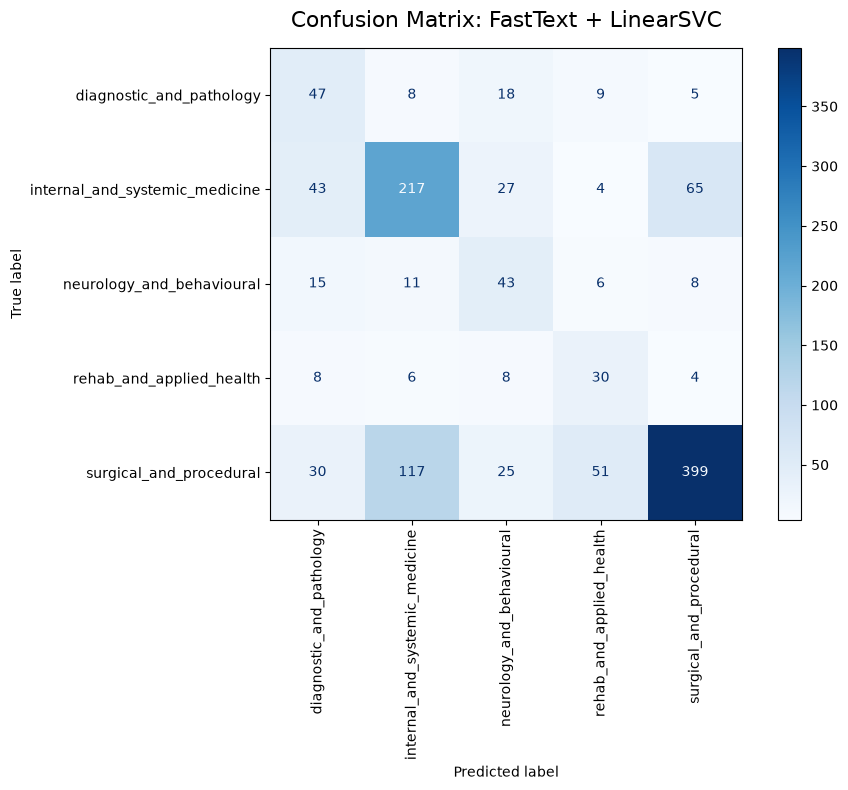

In [14]:
# 5. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate and display the matrix
cm = confusion_matrix(y_test, y_pred_final, labels=logreg_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg_pipeline.classes_)

# Apply a clean colormap and rotate the x-axis labels so they do not overlap
disp.plot(cmap='Blues', ax=ax, xticks_rotation=90)

# Add titles and formatting
plt.title('Confusion Matrix: FastText + LinearSVC', fontsize=16, pad=15)
plt.tight_layout()

# Render the plot
plt.show()